<>:25: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
<>:25: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
C:\Users\lowel\AppData\Local\Temp\ipykernel_4688\3209295809.py:25: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
  ax2.set_title('Step Response: $\Theta_2(t)$')


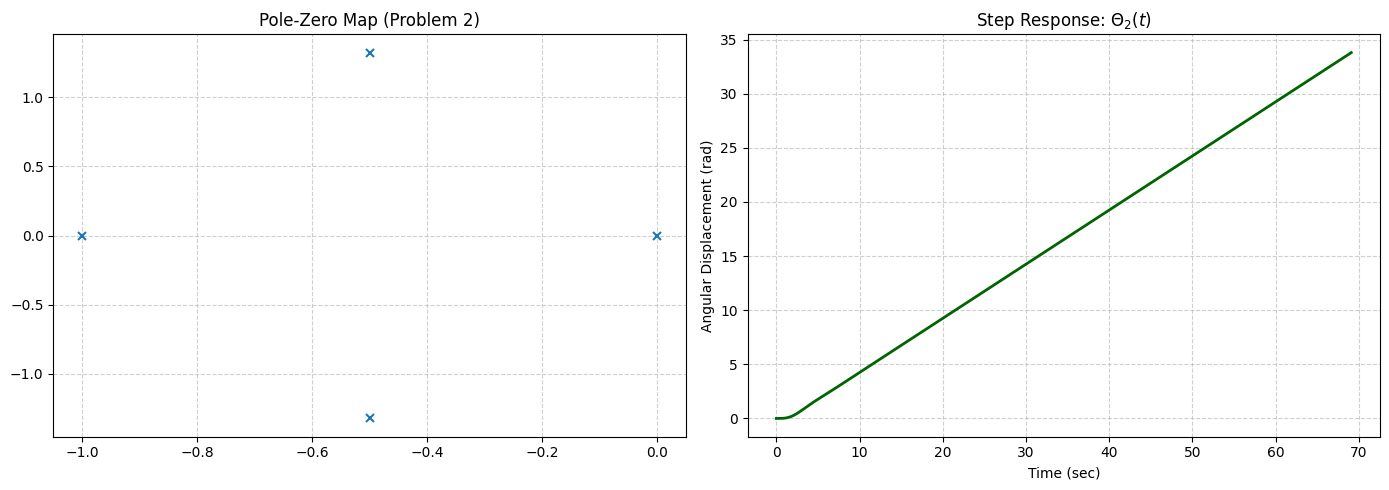

System Poles: [-0.5+1.32287566j -0.5-1.32287566j -1. +0.j          0. +0.j        ]
The system is Marginally Stable (contains an integrator).


In [1]:
import control as ct
import matplotlib.pyplot as plt
import numpy as np

# Define the Transfer Function G(s) = Theta2(s) / T(s)
# Numerator: 1
# Denominator: s^4 + 2s^3 + 3s^2 + 2s
num = [1]
den = [1, 2, 3, 2, 0] # Note: the 0 at the end represents a pole at the origin (integrator)

sys = ct.TransferFunction(num, den)

# Setup the plotting area
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Pole-Zero Map
ct.pole_zero_plot(sys, ax=ax1)
ax1.set_title('Pole-Zero Map (Problem 2)')
ax1.grid(True, which='both', linestyle='--', alpha=0.6)

# 2. Step Response
# Because there is a pole at s=0, the response will ramp up (it's an integrator system)
t, y = ct.step_response(sys)
ax2.plot(t, y, lw=2, color='darkgreen')
ax2.set_title('Step Response: $\Theta_2(t)$')
ax2.set_xlabel('Time (sec)')
ax2.set_ylabel('Angular Displacement (rad)')
ax2.grid(True, which='both', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Output the stability check
poles = ct.poles(sys)
print(f"System Poles: {poles}")
if any(np.real(poles) > 0):
    print("The system is Unstable.")
elif any(np.real(poles) == 0):
    print("The system is Marginally Stable (contains an integrator).")
else:
    print("The system is Stable.")